# Part 1 — GPU-Accelerated Weibull Distribution Fitting

## Notebook: `part1_gpu_weibull/01_gpu_weibull.ipynb`

COMP6940 Assignment 2 Part 1 specifications:
- load the NASA C-MAPSS FD001 engine run-to-failure data
- extract the 100 engine failure times
- fit a 2-parameter Weibull distribution using:
  - a **CPU baseline** with SciPy
  - a **JAX implementation** using `jax.grad`
- benchmark the fitting time
- visualize the fitted Weibull distribution and survival curve
- recommend a preventive maintenance cycle based on the fitted model


## A. Setup and Imports

In [20]:
pip install -U jax

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\vishn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\vishn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from scipy.optimize import minimize
from scipy.stats import weibull_min

#optional: make plots a bit cleaner
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print("JAX version:", jax.__version__)
print("Available JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())


JAX version: 0.9.2
Available JAX devices: [CpuDevice(id=0)]
Default backend: cpu


## B. Data Ingestion and Time-to-Failure Extraction

1. Load `train_FD001.txt` and assign column names.
2. Extract the maximum cycle per engine unit to get 100 failure times.
3. Print the failure times and report mean, median, min, and max.
4. Plot a histogram of the 100 failure times.


In [23]:
#locate the raw FD001 file
candidate_paths = [
    Path(r"C:\\Users\\vishn\\Desktop\\bigDataA2\\CMaps\\train_FD001.txt"),  # your local path
    Path("data/raw/cmapss/train_FD001.txt"),                         # assignment spec (IMPORTANT)
    Path("../data/raw/train_FD001.txt"),                             # fallback
    Path("data/raw/train_FD001.txt"),                                # fallback
]

data_path = None
for path in candidate_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find train_FD001.txt. Put the raw file in '../data/raw/cmapss/' "
        "or 'data/raw/cmapss/' to match the assignment specification."
    )

print("Using raw data file:", data_path.resolve())

#C-MAPSS FD001 column names
column_names = (
    ["unit", "cycle", "setting1", "setting2", "setting3"] +
    [f"s{i}" for i in range(1, 22)]
)

#load raw data
df = pd.read_csv(
    data_path,
    sep=r"\s+",
    header=None,
    names=column_names
)

print("Raw dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Using raw data file: C:\Users\vishn\Desktop\bigDataA2\CMaps\train_FD001.txt
Raw dataset shape: (20631, 26)

First 5 rows:


,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [24]:
#extract time-to-failure (TTF): max cycle per engine unit
failure_times = (
    df.groupby("unit", as_index=True)["cycle"]
      .max()
      .sort_index()
      .astype(int)
)

t = failure_times.to_numpy(dtype=np.float64)

print("Number of engine units:", failure_times.shape[0])
print("\n100 observed failure times (cycles):")
print(t)

summary_stats = pd.Series({
    "mean_failure_time": float(np.mean(t)),
    "median_failure_time": float(np.median(t)),
    "min_failure_time": float(np.min(t)),
    "max_failure_time": float(np.max(t)),
})

print("\nSummary statistics for failure times:")
print(summary_stats.to_string())


Number of engine units: 100

100 observed failure times (cycles):
[192. 287. 179. 189. 269. 188. 259. 150. 201. 222. 240. 170. 163. 180.
 207. 209. 276. 195. 158. 234. 195. 202. 168. 147. 230. 199. 156. 165.
 163. 194. 234. 191. 200. 195. 181. 158. 170. 194. 128. 188. 216. 196.
 207. 192. 158. 256. 214. 231. 215. 198. 213. 213. 195. 257. 193. 275.
 137. 147. 231. 172. 185. 180. 174. 283. 153. 202. 313. 199. 362. 137.
 208. 213. 213. 166. 229. 210. 154. 231. 199. 185. 240. 214. 293. 267.
 188. 278. 178. 213. 217. 154. 135. 341. 155. 258. 283. 336. 202. 156.
 185. 200.]

Summary statistics for failure times:
mean_failure_time      206.31
median_failure_time    199.00
min_failure_time       128.00
max_failure_time       362.00


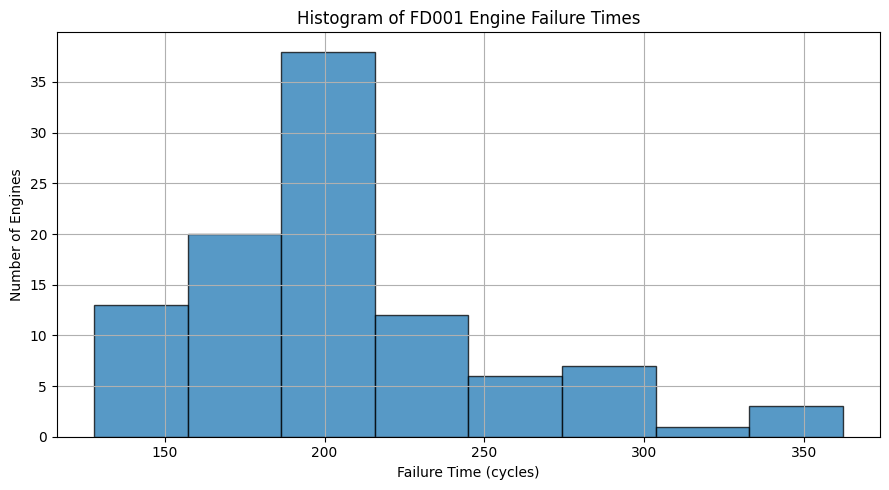

In [25]:
#histogram of failure times
plt.figure()
plt.hist(t, bins="sturges", edgecolor="black", alpha=0.75)
plt.title("Histogram of FD001 Engine Failure Times")
plt.xlabel("Failure Time (cycles)")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()


## C. CPU Baseline — Weibull MLE with SciPy


In [26]:
def weibull_nll_numpy(params, x):
    """Negative log-likelihood for the 2-parameter Weibull distribution.

    Parameters are optimized in log-space:
    - params[0] = log(k)
    - params[1] = log(lambda)
    """
    log_k, log_lam = params
    k = np.exp(log_k)
    lam = np.exp(log_lam)

    if np.any(x <= 0):
        raise ValueError("Weibull MLE requires strictly positive failure times.")

    n = x.size
    ll = (
        n * np.log(k)
        - n * k * np.log(lam)
        + (k - 1.0) * np.sum(np.log(x))
        - np.sum((x / lam) ** k)
    )
    return -ll

initial_params = np.array([0.0, np.log(np.mean(t))], dtype=np.float64)

cpu_start = time.perf_counter()
cpu_result = minimize(
    fun=weibull_nll_numpy,
    x0=initial_params,
    args=(t,),
    method="L-BFGS-B"
)
cpu_end = time.perf_counter()

cpu_time = cpu_end - cpu_start
cpu_k = float(np.exp(cpu_result.x[0]))
cpu_lam = float(np.exp(cpu_result.x[1]))

print("CPU optimization success:", cpu_result.success)
print("CPU message:", cpu_result.message)
print(f"CPU Weibull estimate: k = {cpu_k:.6f}, lambda = {cpu_lam:.6f}")
print(f"CPU wall-clock fit time: {cpu_time:.6f} seconds")


CPU optimization success: True
CPU message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
CPU Weibull estimate: k = 4.408526, lambda = 225.025671
CPU wall-clock fit time: 0.005941 seconds


## D. GPU Implementation — Weibull MLE with JAX

1. Implement the Weibull log-likelihood in JAX.
2. Use `jax.grad` to compute gradients.
3. Fit the distribution with a gradient-based optimizer.
4. Log and report the fitting time.
5. Report and interpret the estimated `k` and `λ`.


In [27]:
#convert observed failure times to a JAX array
x_jax = jnp.array(t, dtype=jnp.float32)

def weibull_nll_jax(params, x):
    """JAX negative log-likelihood for a 2-parameter Weibull model.

    params[0] = log(k)
    params[1] = log(lambda)
    We optimize in log-space to enforce k > 0 and lambda > 0.
    """
    log_k, log_lam = params
    k = jnp.exp(log_k)
    lam = jnp.exp(log_lam)

    n = x.shape[0]
    ll = (
        n * jnp.log(k)
        - n * k * jnp.log(lam)
        + (k - 1.0) * jnp.sum(jnp.log(x))
        - jnp.sum((x / lam) ** k)
    )
    return -ll

grad_nll_jax = jax.grad(weibull_nll_jax)

@jax.jit
def gradient_step(params, x, learning_rate):
    grads = grad_nll_jax(params, x)
    return params - learning_rate * grads


In [28]:
#gradient-descent optimization in JAX
jax_params = jnp.array([0.0, jnp.log(jnp.mean(x_jax))], dtype=jnp.float32)
learning_rate = 0.001
n_steps = 5000

loss_history = []

#warm-up call so JIT compilation is not mixed into the timed loop too heavily
_ = gradient_step(jax_params, x_jax, learning_rate).block_until_ready()

jax_start = time.perf_counter()
for step in range(n_steps):
    jax_params = gradient_step(jax_params, x_jax, learning_rate)
    if step % 100 == 0 or step == n_steps - 1:
        current_loss = float(weibull_nll_jax(jax_params, x_jax))
        loss_history.append((step, current_loss))

#ensure all device work completes before stopping the timer
jax_params.block_until_ready()
jax_end = time.perf_counter()

jax_time = jax_end - jax_start
jax_k = float(jnp.exp(jax_params[0]))
jax_lam = float(jnp.exp(jax_params[1]))

print(f"JAX Weibull estimate: k = {jax_k:.6f}, lambda = {jax_lam:.6f}")
print(f"JAX wall-clock fit time: {jax_time:.6f} seconds")

print("\nSelected optimization checkpoints:")
for step, loss in loss_history[:10]:
    print(f"Step {step:>4}: NLL = {loss:.6f}")
if len(loss_history) > 10:
    print("...")
    for step, loss in loss_history[-5:]:
        print(f"Step {step:>4}: NLL = {loss:.6f}")


JAX Weibull estimate: k = 4.408710, lambda = 225.025558
JAX wall-clock fit time: 0.225834 seconds

Selected optimization checkpoints:
Step    0: NLL = 623.900879
Step  100: NLL = 530.749146
Step  200: NLL = 530.749146
Step  300: NLL = 530.749146
Step  400: NLL = 530.749146
Step  500: NLL = 530.749146
Step  600: NLL = 530.749146
Step  700: NLL = 530.749146
Step  800: NLL = 530.749146
Step  900: NLL = 530.749146
...
Step 4600: NLL = 530.749146
Step 4700: NLL = 530.749146
Step 4800: NLL = 530.749146
Step 4900: NLL = 530.749146
Step 4999: NLL = 530.748962


In [29]:
#compare CPU and JAX estimates/ timings
comparison = pd.DataFrame({
    "Implementation": ["CPU (SciPy)", "JAX"],
    "Shape k": [cpu_k, jax_k],
    "Scale lambda": [cpu_lam, jax_lam],
    "Wall-clock time (s)": [cpu_time, jax_time]
})

display(comparison)


,Implementation,Shape k,Scale lambda,Wall-clock time (s)
0,CPU (SciPy),4.408526,225.025671,0.005941
1,JAX,4.408710,225.025558,0.225834


In [30]:
#interpret the fittted shape parameter from the JAX model
print(f"Estimated JAX shape parameter k = {jax_k:.6f}")
print(f"Estimated JAX scale parameter lambda = {jax_lam:.6f}")

if jax_k < 1:
    interpretation = (
        "k < 1, which suggests a decreasing failure rate over time "
        "(early-life failures / infant mortality pattern)."
    )
elif np.isclose(jax_k, 1.0, atol=0.05):
    interpretation = (
        "k is approximately 1, which suggests an approximately constant failure rate "
        "(close to the exponential model)."
    )
else:
    interpretation = (
        "k > 1, which suggests an increasing failure rate over time "
        "(wear-out behaviour)."
    )

print("\nInterpretation of the shape parameter:")
print(interpretation)


Estimated JAX shape parameter k = 4.408710
Estimated JAX scale parameter lambda = 225.025558

Interpretation of the shape parameter:
k > 1, which suggests an increasing failure rate over time (wear-out behaviour).


## E. Required Visualizations and Analysis

### 1. Weibull fit plot
Overlay the fitted Weibull PDF on the histogram of the 100 observed failure times and include the estimated parameters in the legend.

### 2. Survival curve
Plot the fitted survival function and mark:
- `R(t) = 0.9`  → time by which 10% of engines have failed
- `R(t) = 0.5`  → median life


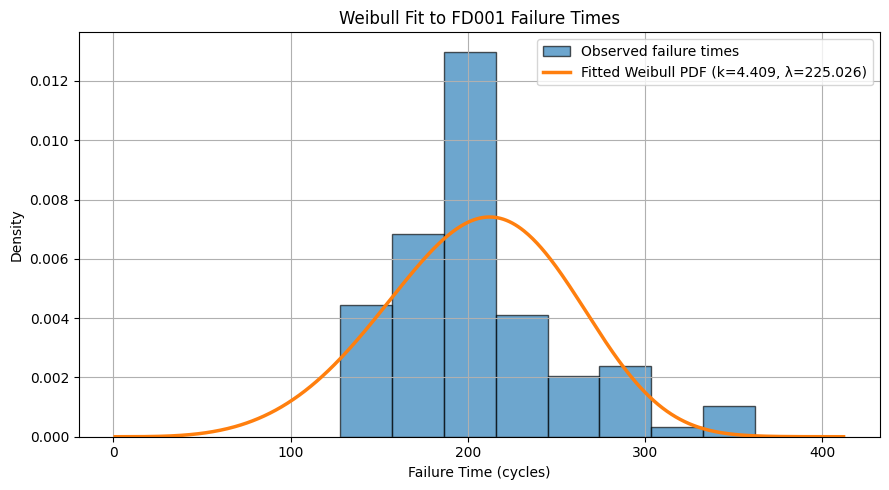

In [31]:
#use the JAX estimates for the final plots
plot_k = jax_k
plot_lam = jax_lam

t_grid = np.linspace(1, t.max() + 50, 500)
pdf_grid = weibull_min.pdf(t_grid, c=plot_k, scale=plot_lam)

plt.figure()
plt.hist(
    t,
    bins="sturges",
    density=True,
    edgecolor="black",
    alpha=0.65,
    label="Observed failure times"
)
plt.plot(
    t_grid,
    pdf_grid,
    linewidth=2.5,
    label=f"Fitted Weibull PDF (k={plot_k:.3f}, λ={plot_lam:.3f})"
)
plt.title("Weibull Fit to FD001 Failure Times")
plt.xlabel("Failure Time (cycles)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


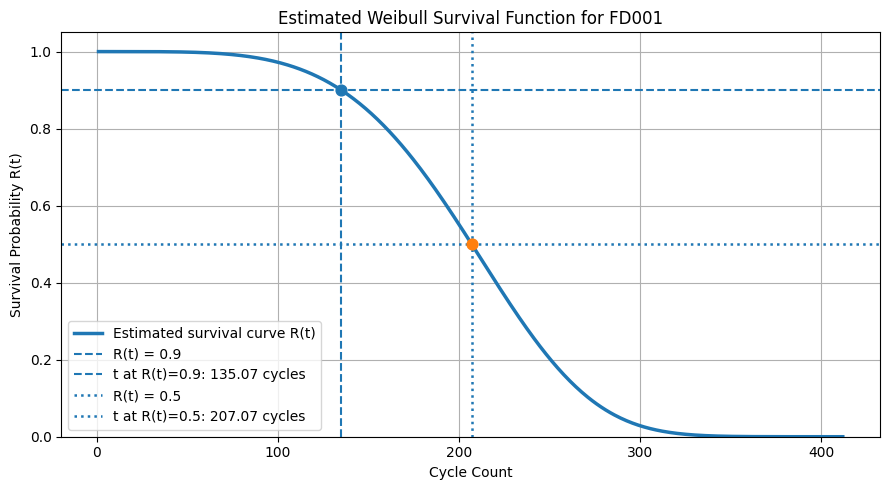

Cycle count for 90% survival: 135.07
Median life cycle count (50% survival): 207.07


In [32]:
#survival curve and quantile markers
survival_grid = weibull_min.sf(t_grid, c=plot_k, scale=plot_lam)

#time where survival = 0.9 means 10% have failed -> CDF = 0.1
t_90_survival = float(weibull_min.ppf(0.10, c=plot_k, scale=plot_lam))

#time where survival = 0.5 means median life -> CDF = 0.5
t_50_survival = float(weibull_min.ppf(0.50, c=plot_k, scale=plot_lam))

plt.figure()
plt.plot(t_grid, survival_grid, linewidth=2.5, label="Estimated survival curve R(t)")
plt.axhline(0.9, linestyle="--", linewidth=1.5, label="R(t) = 0.9")
plt.axvline(t_90_survival, linestyle="--", linewidth=1.5, label=f"t at R(t)=0.9: {t_90_survival:.2f} cycles")
plt.axhline(0.5, linestyle=":", linewidth=1.8, label="R(t) = 0.5")
plt.axvline(t_50_survival, linestyle=":", linewidth=1.8, label=f"t at R(t)=0.5: {t_50_survival:.2f} cycles")

plt.scatter([t_90_survival], [0.9], s=60, zorder=5)
plt.scatter([t_50_survival], [0.5], s=60, zorder=5)

plt.title("Estimated Weibull Survival Function for FD001")
plt.xlabel("Cycle Count")
plt.ylabel("Survival Probability R(t)")
plt.ylim(0, 1.05)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Cycle count for 90% survival: {t_90_survival:.2f}")
print(f"Median life cycle count (50% survival): {t_50_survival:.2f}")


## F. Discussion

### 1. Preventive maintenance recommendation
Using the fitted Weibull survival function, the recommended preventive maintenance threshold is the cycle count where \(R(t)=0.9\), meaning 90% of engines are still expected to survive. In this notebook, that value is computed directly from the fitted model and represents the point by which only 10% of engines are expected to have failed.

This recommendation is appropriate for preventive maintenance because it is conservative: servicing engines at or before this cycle count reduces the probability of in-service failure while still allowing substantial useful life to be used. In practice, this threshold could be adjusted depending on the cost of maintenance versus the cost of unexpected engine failure, but the \(R(t)=0.9\) point provides a reasonable reliability-based benchmark.

### 2. Interpretation of the fitted Weibull parameters
The estimated shape parameter \(k\) is especially important because it describes the failure pattern. If \(k>1\), the failure rate increases over time, which indicates a wear-out mechanism. That interpretation is consistent with turbofan engines, since components generally become more failure-prone as operating cycles accumulate.

The estimated scale parameter \(\lambda\) represents the characteristic life of the population. In a Weibull model, about 63.2% of units are expected to have failed by \(t=\lambda\). Therefore, the fitted \(\lambda\) gives a useful reference point for the typical lifetime scale of engines in the FD001 dataset.

### 3. Is the Weibull distribution a good fit for this data?
Overall, the Weibull distribution appears to be a reasonable fit for these engine failure times. The fitted PDF follows the overall shape of the empirical histogram, and the fitted survival curve decreases smoothly in a way that is plausible for run-to-failure reliability data. In addition, a value of \(k>1\) would support the interpretation that failures become more likely as engines age, which matches expected wear-out behaviour.

However, the fit should still be described as an approximation rather than a perfect representation. The histogram is based on only 100 observed lifetimes, and visual agreement alone is not a formal goodness-of-fit test. The Weibull model may capture the centre of the distribution well while still missing some tail behaviour or engine-to-engine heterogeneity. A stronger validation could include a Weibull probability plot, QQ plot, Kolmogorov-Smirnov test, or comparison against alternative lifetime models such as the lognormal distribution.

### 4. Final conclusion
In summary, the fitted Weibull model is useful for both interpretation and maintenance planning. It suggests a wear-out failure pattern, provides a practical preventive maintenance threshold based on \(R(t)=0.9\), and gives a reasonable overall fit to the observed FD001 failure times. Therefore, it is an appropriate model for this assignment, while still acknowledging that additional fit diagnostics could strengthen the analysis further.

Overall, the Weibull distribution appears to provide a reasonable practical fit to the FD001 failure times, although this conclusion is based mainly on visual and interpretive evidence rather than a formal goodness-of-fit test.


In [33]:
print("=== Preventive Maintenance Recommendation ===")
print(
    f"Based on the fitted Weibull survival function, preventive maintenance should be scheduled "
    f"at or before approximately {t_90_survival:.2f} cycles. "
    f"This corresponds to the point where R(t) = 0.9, meaning about 90% of engines are still "
    f"expected to survive and about 10% are expected to have failed."
)

print("\n=== Interpretation of Weibull Parameters ===")
print(
    f"The estimated shape parameter is k = {plot_k:.4f} and the estimated scale parameter is "
    f"lambda = {plot_lam:.4f}."
)

if plot_k > 1:
    print(
        "Because k > 1, the fitted Weibull model suggests an increasing failure rate over time. "
        "This is consistent with a wear-out failure mechanism, where engines become more likely "
        "to fail as operating cycles accumulate."
    )
elif abs(plot_k - 1) < 0.05:
    print(
        "Because k is approximately 1, the fitted Weibull model suggests an approximately constant "
        "failure rate over time, similar to an exponential model."
    )
else:
    print(
        "Because k < 1, the fitted Weibull model suggests a decreasing failure rate over time, "
        "which would be more consistent with early-life failures than wear-out."
    )

print(
    "The scale parameter lambda represents the characteristic life of the Weibull distribution. "
    "At t = lambda, approximately 63.2% of engines would be expected to have failed."
)

print("\n=== Fit Quality Discussion ===")
print(
    "Overall, the Weibull distribution appears to provide a reasonable fit to the FD001 engine "
    "failure times. The fitted PDF follows the general shape of the empirical histogram, and the "
    "survival curve decreases smoothly in a way that is plausible for run-to-failure reliability data."
)

print(
    "The model is especially interpretable because the estimated shape parameter can be linked "
    "directly to the underlying failure pattern. For engine reliability data, a value of k > 1 "
    "supports the idea of wear-out behaviour, which is mechanically plausible."
)

print(
    "However, the Weibull fit should still be treated as an approximation rather than a perfect "
    "representation of the data. The analysis is based on 100 observed engine lifetimes, and visual "
    "agreement alone is not a formal goodness-of-fit test."
)

print(
    "To strengthen the fit assessment further, one could add a Weibull probability plot, QQ plot, "
    "Kolmogorov-Smirnov test, Anderson-Darling test, or compare the Weibull model with alternative "
    "lifetime distributions such as the lognormal distribution."
)

print("\n=== Final Conclusion ===")
print(
    "The fitted Weibull model is useful for both practical maintenance planning and interpretation "
    "of engine reliability. It provides a defensible preventive maintenance threshold and suggests "
    "a failure pattern that is consistent with the expected ageing behaviour of turbofan engines."
)

print(
    f"The fitted scale parameter is lambda = {plot_lam:.4f}, which represents the characteristic life "
    f"of the engines under the Weibull model."
)

print(
    f"The median life from the fitted survival curve is approximately {t_50_survival:.2f} cycles."
)


=== Preventive Maintenance Recommendation ===
Based on the fitted Weibull survival function, preventive maintenance should be scheduled at or before approximately 135.07 cycles. This corresponds to the point where R(t) = 0.9, meaning about 90% of engines are still expected to survive and about 10% are expected to have failed.

=== Interpretation of Weibull Parameters ===
The estimated shape parameter is k = 4.4087 and the estimated scale parameter is lambda = 225.0256.
Because k > 1, the fitted Weibull model suggests an increasing failure rate over time. This is consistent with a wear-out failure mechanism, where engines become more likely to fail as operating cycles accumulate.
The scale parameter lambda represents the characteristic life of the Weibull distribution. At t = lambda, approximately 63.2% of engines would be expected to have failed.

=== Fit Quality Discussion ===
Overall, the Weibull distribution appears to provide a reasonable fit to the FD001 engine failure times. The 